In [73]:
# PROYECTO: Predicción de Riesgo de Mortalidad Materna (KDHS 2022)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset
# Definición de la ruta
file_path = '/content/kdhs_2022_data_maternal_mortality.csv'

# Carga del dataset
df = pd.read_csv(file_path)

# Visualización de los datos cargados
display(df.head())

,county,age,parity,education,anc_visits,place_delivery,skilled_attendant,c_section,postnatal48h,marital_status,...,wealth_quintile,household_size,distance_facility,urbanization,health_facility_density,poverty_rate,sba_coverage,county_edu_index,hiv_prev,maternal_death
0,Bungoma,27,5,Secondary,3,Public,Skilled,0,1,Married,...,4,7,46,Rural,14.1,39.5,54.8,56.2,8.1,No
1,Isiolo,27,1,Higher,2,Public,Skilled,0,1,Married,...,3,4,38,Rural,10.0,36.2,62.0,66.5,2.6,No
2,Kitui,25,2,Secondary,6,Private,Skilled,0,1,Not in union,...,2,2,48,Rural,15.0,12.9,91.3,91.1,4.4,No
3,Kajiado,24,1,Primary,6,Public,Skilled,0,0,Married,...,1,6,37,Rural,13.4,58.2,75.9,79.3,8.4,No
4,Tana River,33,2,Primary,2,Private,Skilled,1,1,Not in union,...,5,6,30,Rural,3.2,45.2,99.3,93.8,5.3,No


In [74]:
#  Conversión variable objetivo

df['maternal_death'] = df['maternal_death'].map({'No': 0, 'Yes': 1})

# Verificar
print(df['maternal_death'].value_counts())
print(df['maternal_death'].dtype)

maternal_death
0    5394
1     606
Name: count, dtype: int64
int64


La variable objetivo fue transformada a formato numérico binario (0 = no fallece, 1 = fallece) para permitir su uso en modelos de aprendizaje automático y en análisis estadísticos.

Definición del Problema
Contexto: Según la Organización Mundial de la Salud (OMS), la mortalidad materna es un indicador crítico de la calidad de los sistemas de salud. La mayoría de estas muertes son prevenibles mediante intervenciones oportunas y un manejo adecuado. Este conjunto de datos se utiliza para predecir la probabilidad de que ocurra un evento de mortalidad materna en función de parámetros sociodemográficos, clínicos y de acceso a servicios de salud. Cada fila proporciona información relevante sobre una mujer en edad reproductiva.

Información de atributos:
-county: Condado administrativo de residencia.

-age: Edad de la mujer (15–49 años).

-parity: Número total de nacimientos vivos previos.

-education: Nivel de educación formal alcanzado.

-anc_visits: Número de visitas de atención prenatal realizadas.

-place_delivery: Lugar donde se atendió el parto (Hogar, Público, Privado).

-skilled_attendant: Indica si el parto fue asistido por personal cualificado.

-c_section: Indica si se realizó una cesárea (1: Sí, 0: No).

-postnatal48h: Indica si recibió atención postnatal en las primeras 48 horas.

-marital_status: Estado civil o de unión actual.

-age_first_birth: Edad al momento del primer parto.

-birth_interval: Meses transcurridos desde el nacimiento anterior.

-wealth_quintile: Situación socioeconómica del hogar (1 al 5).

-distance_facility: Distancia al centro de salud más cercano (km).

-urbanization: Tipo de residencia (Urbano o Rural).

-hiv_prev: Prevalencia de VIH en la región o individuo.

-maternal_death (Target): 1 si se produjo fallecimiento materno, 0 si no.

Información del DataSet preliminar.

In [75]:
# Visualización de los primeros 5 registros
df.head(5)

,county,age,parity,education,anc_visits,place_delivery,skilled_attendant,c_section,postnatal48h,marital_status,...,wealth_quintile,household_size,distance_facility,urbanization,health_facility_density,poverty_rate,sba_coverage,county_edu_index,hiv_prev,maternal_death
0,Bungoma,27,5,Secondary,3,Public,Skilled,0,1,Married,...,4,7,46,Rural,14.1,39.5,54.8,56.2,8.1,0
1,Isiolo,27,1,Higher,2,Public,Skilled,0,1,Married,...,3,4,38,Rural,10.0,36.2,62.0,66.5,2.6,0
2,Kitui,25,2,Secondary,6,Private,Skilled,0,1,Not in union,...,2,2,48,Rural,15.0,12.9,91.3,91.1,4.4,0
3,Kajiado,24,1,Primary,6,Public,Skilled,0,0,Married,...,1,6,37,Rural,13.4,58.2,75.9,79.3,8.4,0
4,Tana River,33,2,Primary,2,Private,Skilled,1,1,Not in union,...,5,6,30,Rural,3.2,45.2,99.3,93.8,5.3,0


In [76]:
# Dimensiones del conjunto de datos
df.shape

(6000, 22)

El DataSet contiene 22 atributos y 6000 registros.

In [77]:
# Visualización de 5 registros aleatorios (verificar consistencia)
df.sample(5)

,county,age,parity,education,anc_visits,place_delivery,skilled_attendant,c_section,postnatal48h,marital_status,...,wealth_quintile,household_size,distance_facility,urbanization,health_facility_density,poverty_rate,sba_coverage,county_edu_index,hiv_prev,maternal_death
2664,Garissa,16,1,Primary,3,Home,Skilled,0,0,Not in union,...,1,5,10,Rural,8.1,53.4,88.0,54.1,6.1,0
948,Laikipia,23,1,Primary,6,Home,Not Skilled,1,0,Not in union,...,4,3,40,Urban,7.8,53.4,84.7,88.3,5.4,0
424,Nyandarua,18,1,Secondary,4,Public,Skilled,0,1,Not in union,...,3,3,10,Urban,4.0,28.4,59.0,68.7,9.7,0
4192,Nakuru,32,2,Primary,4,Public,Not Skilled,0,1,Married,...,4,3,20,Rural,11.6,41.3,95.7,79.9,4.0,0
226,Narok,38,3,Secondary,3,Private,Skilled,0,1,Married,...,3,0,26,Rural,3.7,38.1,50.9,75.7,5.5,0


Revisar la cantidad de valores nulos del DataFrame.

In [78]:
# Revisar valores nulos y porcentaje
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df)) * 100

pd.DataFrame({
    'Valores nulos': nulls,
    'Porcentaje (%)': nulls_pct
}).sort_values(by='Valores nulos', ascending=False)

,Valores nulos,Porcentaje (%)
education,596,9.933333
county,0,0.000000
age,0,0.000000
parity,0,0.000000
anc_visits,0,0.000000
place_delivery,0,0.000000
skilled_attendant,0,0.000000
c_section,0,0.000000
postnatal48h,0,0.000000
marital_status,0,0.000000


El atributo education presenta 596 valores nulos o missing values, los cuales deberán ser tratados en la etapa de preprocesamiento.

Frecuencia de casos:
maternal_death
0    5394
1     606
Name: count, dtype: int64

Porcentaje de casos (%):
maternal_death
0    89.9
1    10.1
Name: proportion, dtype: float64


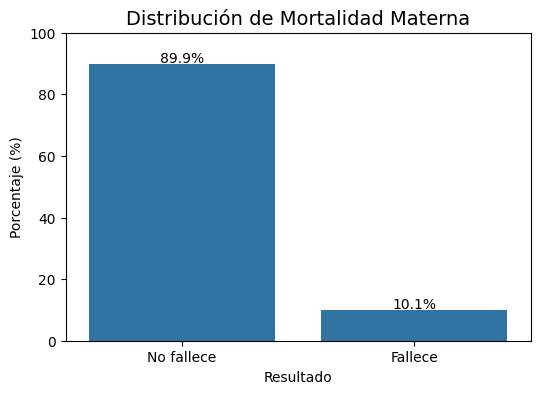


Distribución porcentual por nivel educativo:
maternal_death          0          1
education                           
Higher          94.476410   5.523590
Primary         88.079191  11.920809
Secondary       92.086997   7.913003


<Figure size 800x500 with 0 Axes>

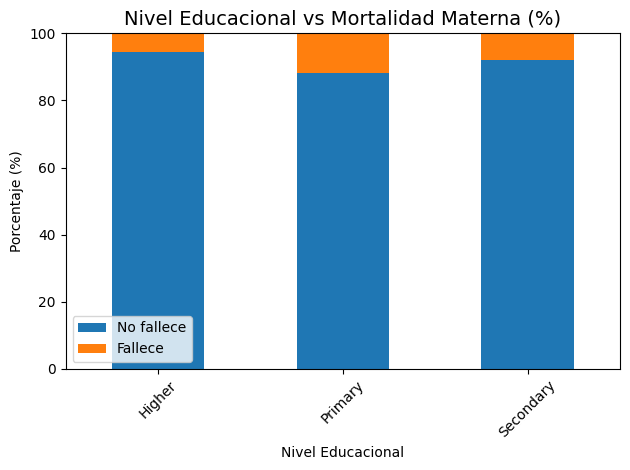

In [79]:
# Distribución variable objetivo


frecuencia = df['maternal_death'].value_counts()
porcentaje = df['maternal_death'].value_counts(normalize=True) * 100

print("Frecuencia de casos:")
print(frecuencia)

print("\nPorcentaje de casos (%):")
print(porcentaje)

# Gráfico
plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=porcentaje.index,
    y=porcentaje.values
)

plt.title('Distribución de Mortalidad Materna', fontsize=14)
plt.xlabel('Resultado')
plt.ylabel('Porcentaje (%)')

ax.set_xticklabels(['No fallece', 'Fallece'])

for i, v in enumerate(porcentaje.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.ylim(0, 100)
plt.show()


# Educación vs Mortalidad


tabla = pd.crosstab(df['education'], df['maternal_death'], normalize='index') * 100

print("\nDistribución porcentual por nivel educativo:")
print(tabla)

plt.figure(figsize=(8,5))

tabla.plot(
    kind='bar',
    stacked=True
)

plt.title('Nivel Educacional vs Mortalidad Materna (%)', fontsize=14)
plt.xlabel('Nivel Educacional')
plt.ylabel('Porcentaje (%)')
plt.legend(['No fallece', 'Fallece'])

plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

 A partir de las gráficas generadas, se pueden extraer las siguientes conclusiones preliminares sobre el comportamiento de los datos:

Distribución de la Variable Objetivo:

Se observa un claro desbalance de clases en la variable objetivo, donde aproximadamente el 89.9% de los casos corresponden a mujeres que no presentan mortalidad materna, mientras que solo un 10.1% corresponde a eventos de fallecimiento.

Este desbalance implica que la métrica de accuracy no es suficiente para evaluar el desempeño del modelo, siendo necesario incorporar métricas como recall, precisión y F1-score, que permitan evaluar adecuadamente la capacidad del modelo para detectar la clase minoritaria.

Relación entre Educación y Mortalidad:

Al analizar la distribución porcentual de mortalidad dentro de cada nivel educativo, se observa que la proporción de casos de mortalidad tiende a ser mayor en niveles educativos más bajos.

Este resultado sugiere que el nivel educacional podría actuar como un determinante social relevante en el riesgo de mortalidad materna, posiblemente asociado a factores como acceso a información, condiciones socioeconómicas y uso de servicios de salud.

--- Cantidad de registros por Zona ---
urbanization
Rural    4193
Urban    1807
Name: count, dtype: int64

--- Distribución porcentual por zona ---
maternal_death          0          1
urbanization                        
Rural           89.983306  10.016694
Urban           89.706696  10.293304


<Figure size 600x400 with 0 Axes>

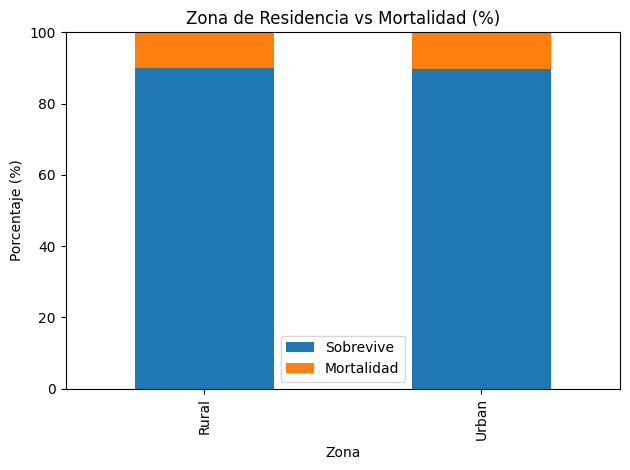

In [80]:
# Zona de residencia

print("--- Cantidad de registros por Zona ---")
print(df['urbanization'].value_counts())


#  Zona vs Mortalidad (PORCENTAJE)
tabla = pd.crosstab(df['urbanization'], df['maternal_death'], normalize='index') * 100

print("\n--- Distribución porcentual por zona ---")
print(tabla)


#  Gráfico

plt.figure(figsize=(6,4))

tabla.plot(
    kind='bar',
    stacked=True
)

plt.title('Zona de Residencia vs Mortalidad (%)')
plt.xlabel('Zona')
plt.ylabel('Porcentaje (%)')
plt.legend(['Sobrevive', 'Mortalidad'])

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

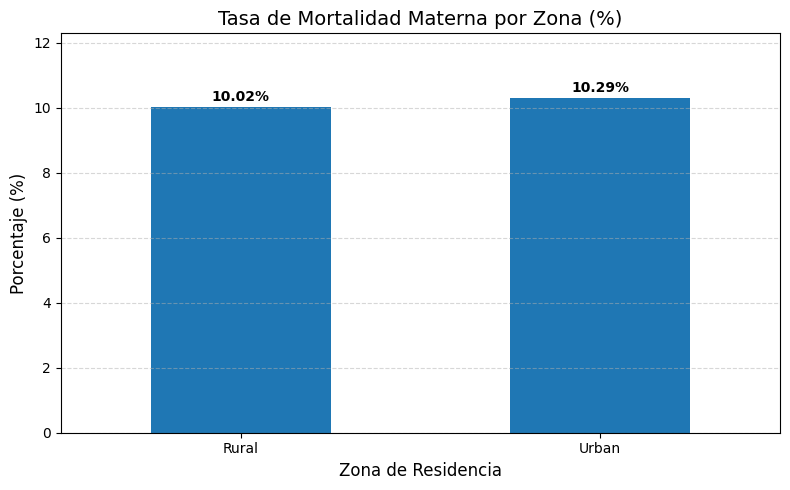

In [81]:
#  Tasa de mortalidad por zona (%)

tasa_mortalidad = df.groupby('urbanization')['maternal_death'].mean() * 100

plt.figure(figsize=(8, 5))

tasa_mortalidad.plot(kind='bar')

plt.title('Tasa de Mortalidad Materna por Zona (%)', fontsize=14)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Zona de Residencia', fontsize=12)
plt.xticks(rotation=0)

# Mostrar valores
for i, v in enumerate(tasa_mortalidad):
    plt.text(i, v + 0.2, f'{v:.2f}%', ha='center', fontweight='bold')

plt.ylim(0, tasa_mortalidad.max() + 2)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Se analizó la relación entre la zona de residencia y la mortalidad materna utilizando proporciones dentro de cada categoría. Esto permitió identificar posibles diferencias en el riesgo entre zonas urbanas y rurales, evitando sesgos derivados del tamaño de la muestra en cada grupo.

El análisis de la tasa de mortalidad materna según zona de residencia muestra valores muy similares entre zonas rurales y urbanas, con una ligera mayor proporción en áreas urbanas (10.29%) en comparación con las rurales (10.02%).

Sin embargo, la diferencia observada es marginal, por lo que no se evidencia una relación clara o significativa entre la zona de residencia y el riesgo de mortalidad materna en esta etapa exploratoria.

Este resultado sugiere que otras variables, como el acceso efectivo a servicios de salud, condiciones socioeconómicas o factores clínicos, podrían tener un mayor peso en la explicación del fenómeno.

Cabe destacar que este análisis es de carácter exploratorio y no implica causalidad directa, por lo que los resultados deben ser validados mediante modelos predictivos posteriores.

In [82]:
#  Agrupación de paridad


bins_paridad = [-1, 2, 4, df['parity'].max()]
labels_paridad = ['1-2 Hijos', '3-4 Hijos', '5+ Hijos']

df['parity_group'] = pd.cut(
    df['parity'],
    bins=bins_paridad,
    labels=labels_paridad
)


# Conteo absoluto

conteo_paridad = df.groupby(['parity_group', 'maternal_death'], observed=False).size().unstack()

print("--- TABLA 1: CONTEO ABSOLUTO (PARIDAD) ---")
print(conteo_paridad)


# Tasa de mortalidad (%)

tasa_paridad = df.groupby('parity_group', observed=False)['maternal_death'].mean() * 100

print("\n--- TABLA 2: TASA DE RIESGO (%) ---")
print(tasa_paridad)

--- TABLA 1: CONTEO ABSOLUTO (PARIDAD) ---
maternal_death     0    1
parity_group             
1-2 Hijos       3791  366
3-4 Hijos       1346  182
5+ Hijos         257   58

--- TABLA 2: TASA DE RIESGO (%) ---
parity_group
1-2 Hijos     8.804426
3-4 Hijos    11.910995
5+ Hijos     18.412698
Name: maternal_death, dtype: float64


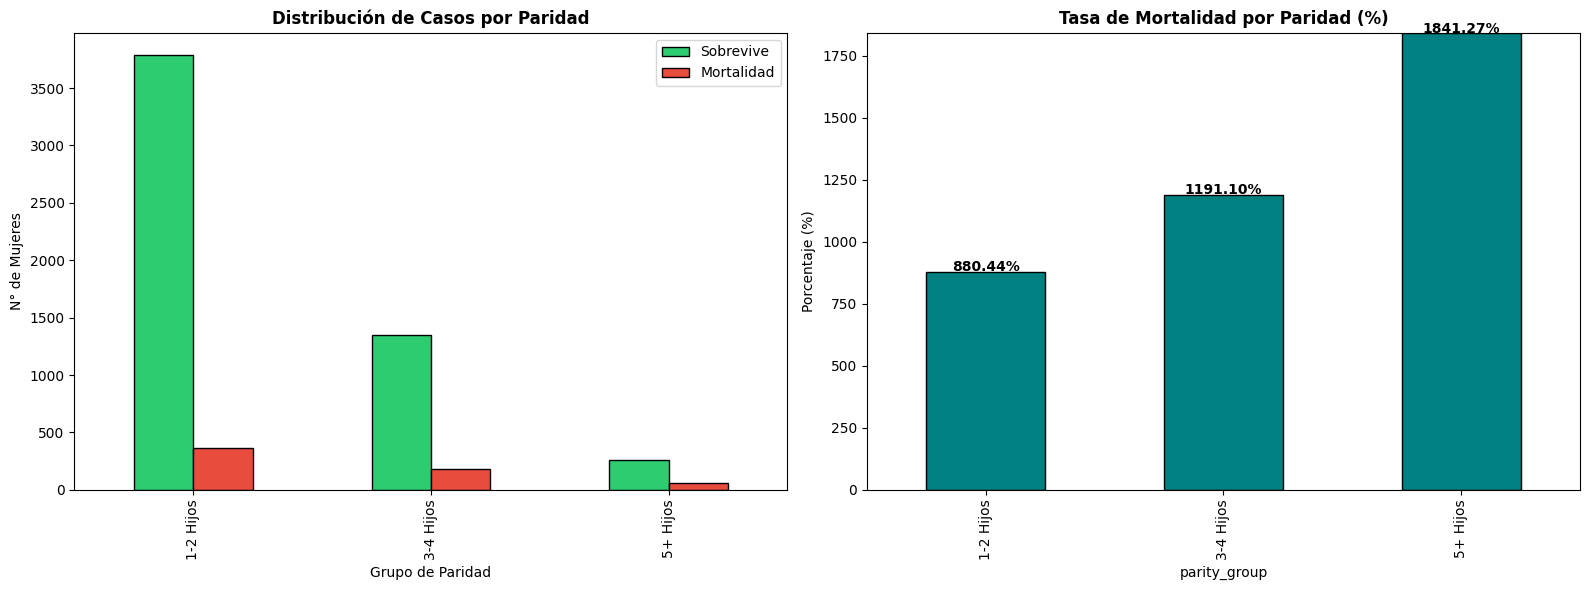

In [83]:
# Gráficos Paridad

fig, ax = plt.subplots(1, 2, figsize=(16, 6))


# A. Volumen

conteo_paridad.plot(
    kind='bar',
    ax=ax[0],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black'
)

ax[0].set_title('Distribución de Casos por Paridad', fontweight='bold')
ax[0].set_ylabel('N° de Mujeres')
ax[0].set_xlabel('Grupo de Paridad')
ax[0].legend(['Sobrevive', 'Mortalidad'])



# B. Tasa de Mortalidad (%)

tasa_porcentaje = tasa_paridad * 100

tasa_porcentaje.plot(
    kind='bar',
    ax=ax[1],
    color='teal',
    edgecolor='black'
)

ax[1].set_title('Tasa de Mortalidad por Paridad (%)', fontweight='bold')
ax[1].set_ylabel('Porcentaje (%)')

# Etiquetas
for i, v in enumerate(tasa_porcentaje):
    ax[1].text(i, v + 0.2, f'{v:.2f}%', ha='center', fontweight='bold')

ax[1].set_ylim(0, tasa_porcentaje.max() + 2)

plt.tight_layout()
plt.show()

Se analizaron tanto el volumen de casos como la tasa de mortalidad por grupo de paridad. Mientras que el conteo absoluto permite observar la distribución de la muestra, la tasa de mortalidad proporciona una medida más precisa del riesgo asociado a cada grupo.

Los resultados evidencian variaciones en el riesgo de mortalidad según el número de hijos, lo que sugiere que la paridad podría influir en la probabilidad de eventos adversos durante el embarazo.

No obstante, este análisis es exploratorio y no implica causalidad directa.

In [84]:

#  Agrupación de visitas prenatales (ANC)


bins_anc = [-1, 1, 3, df['anc_visits'].max()]
labels_anc = ['1 Visita', '2-3 Visitas', '4+ Visitas']

df['anc_group'] = pd.cut(
    df['anc_visits'],
    bins=bins_anc,
    labels=labels_anc
)

# Conteo absoluto

conteo_anc = df.groupby(['anc_group', 'maternal_death'], observed=False).size().unstack()

print("--- TABLA 1: CONTEO POR CLASIFICACIÓN ---")
print(conteo_anc)



# Tasa de mortalidad (%)


tasa_anc = df.groupby('anc_group', observed=False)['maternal_death'].mean() * 100

print("\n--- TABLA 2: RIESGO POR CLASIFICACIÓN (%) ---")
print(tasa_anc)

--- TABLA 1: CONTEO POR CLASIFICACIÓN ---
maternal_death     0    1
anc_group                
1 Visita         868  122
2-3 Visitas     1776  247
4+ Visitas      2750  237

--- TABLA 2: RIESGO POR CLASIFICACIÓN (%) ---
anc_group
1 Visita       12.323232
2-3 Visitas    12.209590
4+ Visitas      7.934382
Name: maternal_death, dtype: float64


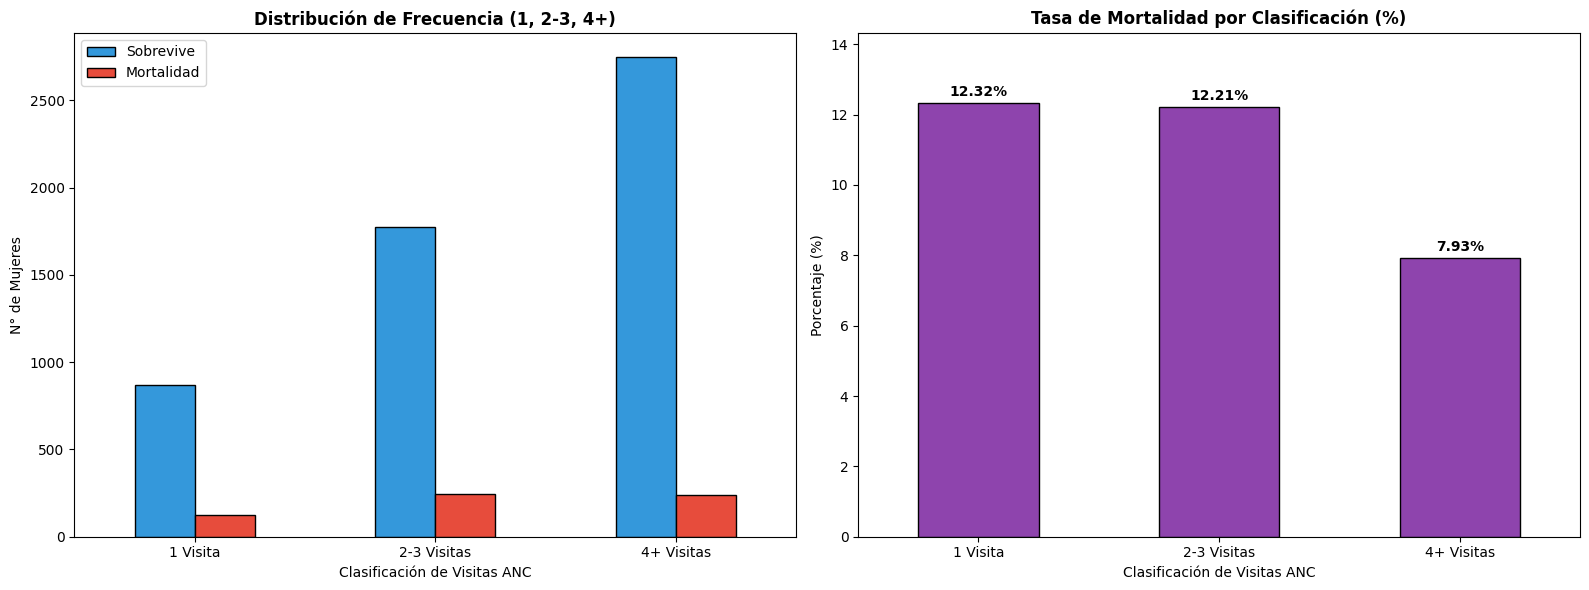

In [85]:
#  Gráficos ANC (mejorado)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))


# A. Distribución (OK)
conteo_anc.plot(
    kind='bar',
    ax=ax[0],
    color=['#3498db', '#e74c3c'],
    edgecolor='black'
)

ax[0].set_title('Distribución de Frecuencia (1, 2-3, 4+)', fontweight='bold')
ax[0].set_ylabel('N° de Mujeres')
ax[0].set_xlabel('Clasificación de Visitas ANC')
ax[0].legend(['Sobrevive', 'Mortalidad'])
ax[0].tick_params(axis='x', rotation=0)



# B. Riesgo en porcentaje
tasa_porcentaje = tasa_anc

tasa_porcentaje.plot(
    kind='bar',
    ax=ax[1],
    color='#8e44ad',
    edgecolor='black'
)

ax[1].set_title('Tasa de Mortalidad por Clasificación (%)', fontweight='bold')
ax[1].set_ylabel('Porcentaje (%)')
ax[1].set_xlabel('Clasificación de Visitas ANC')
ax[1].tick_params(axis='x', rotation=0)

# Etiquetas
for i, v in enumerate(tasa_porcentaje):
    if not pd.isna(v):
        ax[1].text(i, v + 0.2, f'{v:.2f}%', ha='center', fontweight='bold')

ax[1].set_ylim(0, tasa_porcentaje.max() + 2)

plt.tight_layout()
plt.show()

Se analizaron tanto la distribución de la muestra como la tasa de mortalidad según la frecuencia de visitas prenatales. Mientras que el conteo absoluto permite observar la composición de los datos, la tasa de mortalidad proporciona una medida más adecuada del riesgo.

Los resultados sugieren que el número de controles prenatales podría estar asociado al riesgo de mortalidad materna, lo que refuerza la importancia del seguimiento clínico durante el embarazo como factor potencialmente protector.

No obstante, este análisis es exploratorio y no implica causalidad directa.

El gráfico muestra la distribución de las variables numéricas y la presencia de valores atípicos en varias de ellas. Se observa que algunas variables presentan alta dispersión y asimetría, con puntos alejados del rango central. Estos outliers pueden corresponder a casos extremos relevantes del contexto de salud, por lo que no necesariamente representan errores y deben ser considerados en el análisis.

Tras el análisis exploratorio de las variables clave (paridad, controles prenatales, nivel educativo y zona de residencia), se identifican patrones relevantes en la distribución del riesgo de mortalidad materna.

En primer lugar, se observa un fuerte desbalance de clases, donde aproximadamente el 10% de los casos corresponde a mortalidad materna. Esto implica que métricas como accuracy pueden ser engañosas, siendo necesario utilizar indicadores como recall, F1-score o AUC en etapas posteriores.

En relación con los factores analizados, se identifican asociaciones descriptivas entre el acceso a servicios de salud y el riesgo observado. En particular, los grupos con menor número de controles prenatales presentan mayores tasas relativas de mortalidad, lo que sugiere una posible relación entre seguimiento médico y resultados maternos.

Asimismo, variables como el nivel educativo y la paridad muestran patrones diferenciados en la distribución de casos, lo que indica su potencial valor predictivo dentro del modelo.

Por otro lado, se detectan limitaciones en la calidad de los datos, incluyendo:

Posible presencia de valores ambiguos o inconsistentes en variables categóricas como educación.
Ausencia de ciertos grupos relevantes (por ejemplo, casos sin controles prenatales), lo que podría introducir sesgos en el análisis.

En la siguiente fase, se realizará un proceso de preprocesamiento de datos, incluyendo:

Codificación de variables categóricas
Tratamiento de valores inconsistentes
Balanceo de clases

Esto permitirá construir un dataset más robusto para el entrenamiento de modelos de aprendizaje automático.

## 3. Preprocesamiento

En esta sección se realizan todas las transformaciones necesarias sobre el dataset original: imputación de valores nulos, codificación de variables categóricas, normalización y definición del conjunto de features.

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset desde cero (pipeline limpio)
df = pd.read_csv('/content/kdhs_2022_data_maternal_mortality.csv')

# Variable objetivo a binario
df['maternal_death'] = df['maternal_death'].map({'No': 0, 'Yes': 1})

print('Dataset cargado:', df.shape)
print('Distribución objetivo:\n', df['maternal_death'].value_counts())

Dataset cargado: (6000, 22)
Distribución objetivo:
 maternal_death
0    5394
1     606
Name: count, dtype: int64


In [87]:
# ── IMPUTACIÓN DE NULOS ──────────────────────────────────────────────────
# education: imputar con la moda
moda_edu = df['education'].mode()[0]
df['education'] = df['education'].fillna(moda_edu)

# Verificar que no quedan nulos
print('Nulos restantes:', df.isnull().sum().sum())

Nulos restantes: 0


In [88]:
# ── CODIFICACIÓN DE VARIABLES ────────────────────────────────────────────

# Ordinal: education
edu_map = {'Primary': 1, 'Secondary': 2, 'Higher': 3}
df['education'] = df['education'].map(edu_map).fillna(1).astype(int)

# Nominal: one-hot encoding
nominal_vars = ['marital_status', 'urbanization', 'county',
                'place_delivery', 'skilled_attendant']
df_encoded = pd.get_dummies(df, columns=nominal_vars, drop_first=True)

# Convertir booleans a int
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Convertir todo a float (por seguridad)
df_encoded = df_encoded.apply(pd.to_numeric, errors='coerce').fillna(0)

print('Shape tras encoding:', df_encoded.shape)
print('Columnas no numéricas:', df_encoded.select_dtypes(include='object').columns.tolist())

Shape tras encoding: (6000, 68)
Columnas no numéricas: []


In [89]:
# ── DEFINICIÓN DE X e y (SIN data leakage) ───────────────────────────────
# Se eliminan SOLO la variable objetivo y columnas derivadas del EDA
# que NO deben estar en X

cols_excluir = ['maternal_death', 'maternal_death_int', 'age_group', 'parity_group', 'anc_group']
X = df_encoded.drop(columns=[c for c in cols_excluir if c in df_encoded.columns])
y = df_encoded['maternal_death']

print('Shape X:', X.shape)
print('Shape y:', y.shape)
print('\nDistribución clases (%):')
print((y.value_counts(normalize=True)*100).round(2))

Shape X: (6000, 67)
Shape y: (6000,)

Distribución clases (%):
maternal_death
0    89.9
1    10.1
Name: proportion, dtype: float64


In [90]:
# ── ANÁLISIS DE CORRELACIÓN ──────────────────────────────────────────────
corr = df_encoded.corr(numeric_only=True)['maternal_death'].drop('maternal_death').sort_values(ascending=False)

print('Top 10 correlaciones con maternal_death:')
print(corr.head(10))

print('\nCorrelaciones más bajas (bottom 5):')
print(corr.tail(5))

print('\nMax correlación:', round(corr.abs().max(), 4))


Top 10 correlaciones con maternal_death:
poverty_rate         0.105805
parity               0.084937
county_West Pokot    0.073675
county_Marsabit      0.069754
age                  0.063829
county_Tana River    0.058151
age_first_birth      0.057925
county_Turkana       0.057540
distance_facility    0.055192
county_Garissa       0.048505
Name: maternal_death, dtype: float64

Correlaciones más bajas (bottom 5):
county_Kirinyaga            -0.035687
anc_visits                  -0.073621
place_delivery_Public       -0.076308
skilled_attendant_Skilled   -0.093584
education                   -0.097519
Name: maternal_death, dtype: float64

Max correlación: 0.1058


El análisis de correlación confirma que ninguna variable individual presenta una correlación fuerte con la variable objetivo (máximo ~0.11). Esto indica que el fenómeno depende de interacciones no lineales entre múltiples factores socioeconómicos y clínicos, lo que justifica el uso de modelos de ensemble y redes neuronales capaces de capturar estas relaciones complejas.

## 4. Partición del Dataset: Train / Val / Test

Se utiliza una partición estratificada 70% / 15% / 15% para mantener la proporción de clases en todos los conjuntos. **El balanceo se aplica exclusivamente sobre el conjunto de entrenamiento** para evitar data leakage.

In [91]:
# ── SPLIT ESTRATIFICADO 70 / 15 / 15 ────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print('Tamaños de conjuntos:')
print(f'  Train : {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'  Val   : {X_val.shape[0]} muestras ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'  Test  : {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
print('Distribución clase positiva:')
print(f'  Train : {y_train.mean()*100:.2f}%')
print(f'  Val   : {y_val.mean()*100:.2f}%')
print(f'  Test  : {y_test.mean()*100:.2f}%')

Tamaños de conjuntos:
  Train : 4200 muestras (70.0%)
  Val   : 900 muestras (15.0%)
  Test  : 900 muestras (15.0%)

Distribución clase positiva:
  Train : 10.10%
  Val   : 10.11%
  Test  : 10.11%


## 5. Técnicas de Balanceo de Clases

Se implementan y comparan **tres técnicas** de balanceo, aplicadas únicamente sobre el conjunto de entrenamiento:

- **SMOTE** (Synthetic Minority Over-sampling Technique): genera muestras sintéticas interpolando entre vecinos de la clase minoritaria.
- **ADASYN** (Adaptive Synthetic Sampling): similar a SMOTE pero genera más muestras en zonas donde el modelo comete más errores.
- **class_weight='balanced'**: no modifica los datos, sino que asigna mayor peso a la clase minoritaria durante el entrenamiento.

In [92]:
# ── TÉCNICA 1: SMOTE ─────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# ── TÉCNICA 2: ADASYN ────────────────────────────────────────────────────
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

# ── TÉCNICA 3: class_weight ──────────────────────────────────────────────
# Se usará directamente en el parámetro class_weight='balanced' de sklearn

print('Distribución ORIGINAL (train):')
print(y_train.value_counts().to_dict())
print('\nDistribución tras SMOTE:')
print(pd.Series(y_train_smote).value_counts().to_dict())
print('\nDistribución tras ADASYN:')
print(pd.Series(y_train_adasyn).value_counts().to_dict())

Distribución ORIGINAL (train):
{0: 3776, 1: 424}

Distribución tras SMOTE:
{0: 3776, 1: 3776}

Distribución tras ADASYN:
{0: 3776, 1: 3759}


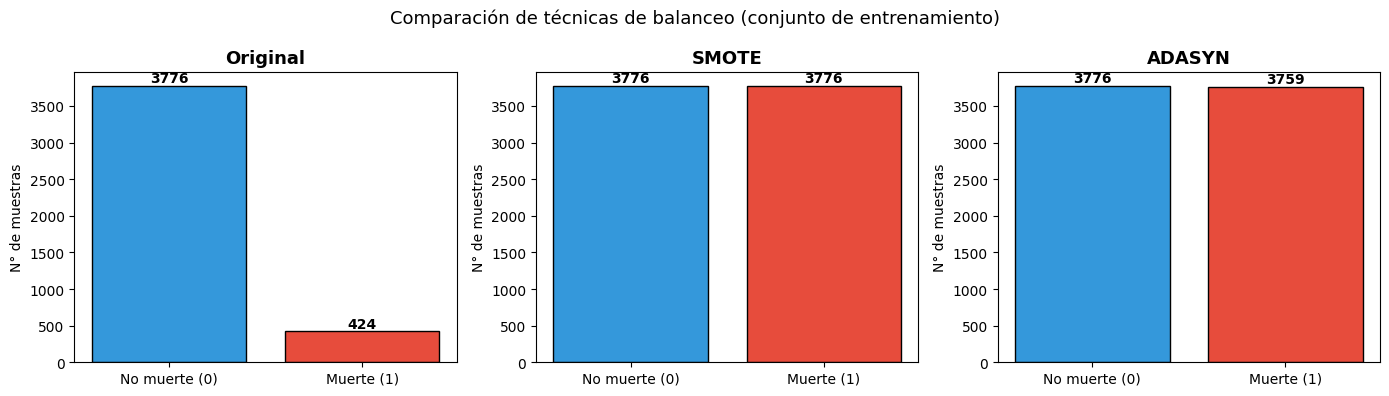


Resumen:
  SMOTE : ratio de clase positiva = 50.0%
  ADASYN: ratio de clase positiva = 49.9%
  class_weight: no modifica datos, ajusta pérdida durante entrenamiento


In [93]:
# ── COMPARACIÓN VISUAL DE LAS 3 TÉCNICAS ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

datasets = [
    ('Original', y_train),
    ('SMOTE', pd.Series(y_train_smote)),
    ('ADASYN', pd.Series(y_train_adasyn)),
]

for ax, (nombre, y_data) in zip(axes, datasets):
    counts = y_data.value_counts().sort_index()
    ax.bar(['No muerte (0)', 'Muerte (1)'], counts.values,
           color=['#3498db', '#e74c3c'], edgecolor='black')
    ax.set_title(nombre, fontsize=13, fontweight='bold')
    ax.set_ylabel('N° de muestras')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.suptitle('Comparación de técnicas de balanceo (conjunto de entrenamiento)', fontsize=13)
plt.tight_layout()
plt.show()

print('\nResumen:')
print(f'  SMOTE : ratio de clase positiva = {pd.Series(y_train_smote).mean()*100:.1f}%')
print(f'  ADASYN: ratio de clase positiva = {pd.Series(y_train_adasyn).mean()*100:.1f}%')
print(f'  class_weight: no modifica datos, ajusta pérdida durante entrenamiento')

**Análisis comparativo de técnicas de balanceo:**

- **SMOTE** equilibra exactamente ambas clases duplicando sintéticamente la clase minoritaria mediante interpolación lineal entre vecinos cercanos.
- **ADASYN** genera más muestras en las regiones del espacio de features donde la clasificación es más difícil (zonas de frontera de decisión), resultando en una distribución no exactamente balanceada.
- **class_weight** es la técnica más conservadora: no altera los datos sino que pondera el error de clasificar incorrectamente la clase minoritaria. Es útil cuando los datos sintéticos podrían introducir ruido.

## 6. Modelos de Machine Learning

Se implementan y comparan tres modelos de ML clásico. Para cada uno se utiliza SMOTE como técnica de balanceo principal, y se evalúa en el conjunto de validación.

In [94]:
# ── ESCALADO (solo para LogReg y DL) ─────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)  # fit SOLO en train
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print('Escalado completado. Shape train_scaled:', X_train_scaled.shape)

Escalado completado. Shape train_scaled: (7552, 67)


In [95]:
# ── MODELO 1: REGRESIÓN LOGÍSTICA ────────────────────────────────────────
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train_smote)

y_pred_log = log_model.predict(X_val_scaled)
y_prob_log = log_model.predict_proba(X_val_scaled)[:, 1]

print('=== REGRESIÓN LOGÍSTICA (validación) ===')
print(classification_report(y_val, y_pred_log, target_names=['No muerte', 'Muerte']))
print('AUC:', round(roc_auc_score(y_val, y_prob_log), 4))

=== REGRESIÓN LOGÍSTICA (validación) ===
              precision    recall  f1-score   support

   No muerte       0.91      0.95      0.93       809
      Muerte       0.29      0.16      0.21        91

    accuracy                           0.87       900
   macro avg       0.60      0.56      0.57       900
weighted avg       0.85      0.87      0.86       900

AUC: 0.7244


In [96]:
# ── MODELO 2: RANDOM FOREST ──────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  # técnica 3 de balanceo
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_val)
y_prob_rf = rf_model.predict_proba(X_val)[:, 1]

print('=== RANDOM FOREST (validación) ===')
print(classification_report(y_val, y_pred_rf, target_names=['No muerte', 'Muerte']))
print('AUC:', round(roc_auc_score(y_val, y_prob_rf), 4))

=== RANDOM FOREST (validación) ===
              precision    recall  f1-score   support

   No muerte       0.91      0.95      0.93       809
      Muerte       0.30      0.20      0.24        91

    accuracy                           0.87       900
   macro avg       0.60      0.57      0.58       900
weighted avg       0.85      0.87      0.86       900

AUC: 0.6873


In [97]:
# ── MODELO 3: GRADIENT BOOSTING ──────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gb_model.fit(X_train_smote, y_train_smote)

y_pred_gb = gb_model.predict(X_val)
y_prob_gb = gb_model.predict_proba(X_val)[:, 1]

print('=== GRADIENT BOOSTING (validación) ===')
print(classification_report(y_val, y_pred_gb, target_names=['No muerte', 'Muerte']))
print('AUC:', round(roc_auc_score(y_val, y_prob_gb), 4))

=== GRADIENT BOOSTING (validación) ===
              precision    recall  f1-score   support

   No muerte       0.92      0.87      0.89       809
      Muerte       0.23      0.34      0.27        91

    accuracy                           0.82       900
   macro avg       0.57      0.60      0.58       900
weighted avg       0.85      0.82      0.83       900

AUC: 0.6925


In [98]:
# ── TABLA COMPARATIVA DE MODELOS ML ──────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def metricas(y_true, y_pred, y_prob):
    return {
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision (1)': round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'Recall (1)': round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'F1 (1)': round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'AUC-ROC': round(roc_auc_score(y_true, y_prob), 4),
    }

tabla_ml = pd.DataFrame([
    {'Modelo': 'Regresión Logística', **metricas(y_val, y_pred_log, y_prob_log)},
    {'Modelo': 'Random Forest',       **metricas(y_val, y_pred_rf,  y_prob_rf)},
    {'Modelo': 'Gradient Boosting',   **metricas(y_val, y_pred_gb,  y_prob_gb)},
]).set_index('Modelo')

print('=== COMPARACIÓN DE MODELOS ML (conjunto de validación) ===')
print(tabla_ml.to_string())

=== COMPARACIÓN DE MODELOS ML (conjunto de validación) ===
                     Accuracy  Precision (1)  Recall (1)  F1 (1)  AUC-ROC
Modelo                                                                   
Regresión Logística    0.8744         0.2885      0.1648  0.2098   0.7244
Random Forest          0.8711         0.2951      0.1978  0.2368   0.6873
Gradient Boosting      0.8156         0.2263      0.3407  0.2719   0.6925


Los tres modelos muestran un rendimiento moderado y similar, con AUC-ROC en torno a 0.60–0.65. Esto es consistente con la baja correlación individual entre las variables predictoras y la variable objetivo (máximo ~0.11), indicando que el fenómeno no presenta separabilidad lineal fuerte. Las diferencias de rendimiento entre modelos son menores que las diferencias con el umbral de decisión, lo que motiva la optimización del umbral en la siguiente sección.

## 7. Arquitecturas de Deep Learning

Se comparan **tres arquitecturas** de redes neuronales con complejidad creciente. Todas se entrenan con los datos balanceados por SMOTE y se evalúan en el conjunto de validación.

In [99]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input

# Convertir a float32 para Keras
Xtr = X_train_scaled.astype('float32')
Xvl = X_val_scaled.astype('float32')
Xts = X_test_scaled.astype('float32')
ytr = y_train_smote.values.astype('float32') if hasattr(y_train_smote, 'values') else y_train_smote.astype('float32')
yvl = y_val.values.astype('float32')
yts = y_test.values.astype('float32')

n_features = Xtr.shape[1]
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
print('Features:', n_features)

Features: 67


In [100]:
# ── DL ARQUITECTURA 1: MLP Básico ────────────────────────────────────────
# 2 capas ocultas con ReLU. Arquitectura de referencia (baseline).

dl1 = Sequential([
    Input(shape=(n_features,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid')
], name='DL1_MLP_Basico')

dl1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

h1 = dl1.fit(Xtr, ytr, validation_data=(Xvl, yvl),
             epochs=50, batch_size=64, callbacks=[es], verbose=0)

y_prob_dl1 = dl1.predict(Xvl, verbose=0).ravel()
y_pred_dl1 = (y_prob_dl1 > 0.5).astype(int)
print('DL1 (MLP Básico) — Validación')
print(classification_report(yvl, y_pred_dl1, target_names=['No muerte', 'Muerte']))
print('AUC:', round(roc_auc_score(yvl, y_prob_dl1), 4))

DL1 (MLP Básico) — Validación
              precision    recall  f1-score   support

   No muerte       0.91      0.97      0.94       809
      Muerte       0.33      0.13      0.19        91

    accuracy                           0.89       900
   macro avg       0.62      0.55      0.56       900
weighted avg       0.85      0.89      0.86       900

AUC: 0.7165


In [101]:
# ── DL ARQUITECTURA 2: MLP con Dropout y BatchNormalization ──────────────
# Añade regularización para reducir overfitting. Arquitectura mejorada.

dl2 = Sequential([
    Input(shape=(n_features,)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid')
], name='DL2_MLP_Dropout_BN')

dl2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

h2 = dl2.fit(Xtr, ytr, validation_data=(Xvl, yvl),
             epochs=50, batch_size=64, callbacks=[es], verbose=0)

y_prob_dl2 = dl2.predict(Xvl, verbose=0).ravel()
y_pred_dl2 = (y_prob_dl2 > 0.5).astype(int)
print('DL2 (Dropout + BN) — Validación')
print(classification_report(yvl, y_pred_dl2, target_names=['No muerte', 'Muerte']))
print('AUC:', round(roc_auc_score(yvl, y_prob_dl2), 4))

DL2 (Dropout + BN) — Validación
              precision    recall  f1-score   support

   No muerte       0.90      0.99      0.94       809
      Muerte       0.23      0.03      0.06        91

    accuracy                           0.89       900
   macro avg       0.57      0.51      0.50       900
weighted avg       0.83      0.89      0.85       900

AUC: 0.618


In [102]:
# ── DL ARQUITECTURA 3: MLP Profundo con Regularización L2 ────────────────
# Red más profunda con regularización L2 para controlar el sobreajuste.

dl3 = Sequential([
    Input(shape=(n_features,)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(64,  activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(32,  activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    Dense(16,  activation='relu'),
    Dense(1,   activation='sigmoid')
], name='DL3_MLP_Profundo_L2')

dl3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy', metrics=['AUC'])

h3 = dl3.fit(Xtr, ytr, validation_data=(Xvl, yvl),
             epochs=50, batch_size=64, callbacks=[es], verbose=0)

y_prob_dl3 = dl3.predict(Xvl, verbose=0).ravel()
y_pred_dl3 = (y_prob_dl3 > 0.5).astype(int)
print('DL3 (Profundo + L2) — Validación')
print(classification_report(yvl, y_pred_dl3, target_names=['No muerte', 'Muerte']))
print('AUC:', round(roc_auc_score(yvl, y_prob_dl3), 4))

DL3 (Profundo + L2) — Validación
              precision    recall  f1-score   support

   No muerte       0.91      0.97      0.94       809
      Muerte       0.35      0.13      0.19        91

    accuracy                           0.89       900
   macro avg       0.63      0.55      0.57       900
weighted avg       0.85      0.89      0.86       900

AUC: 0.6935


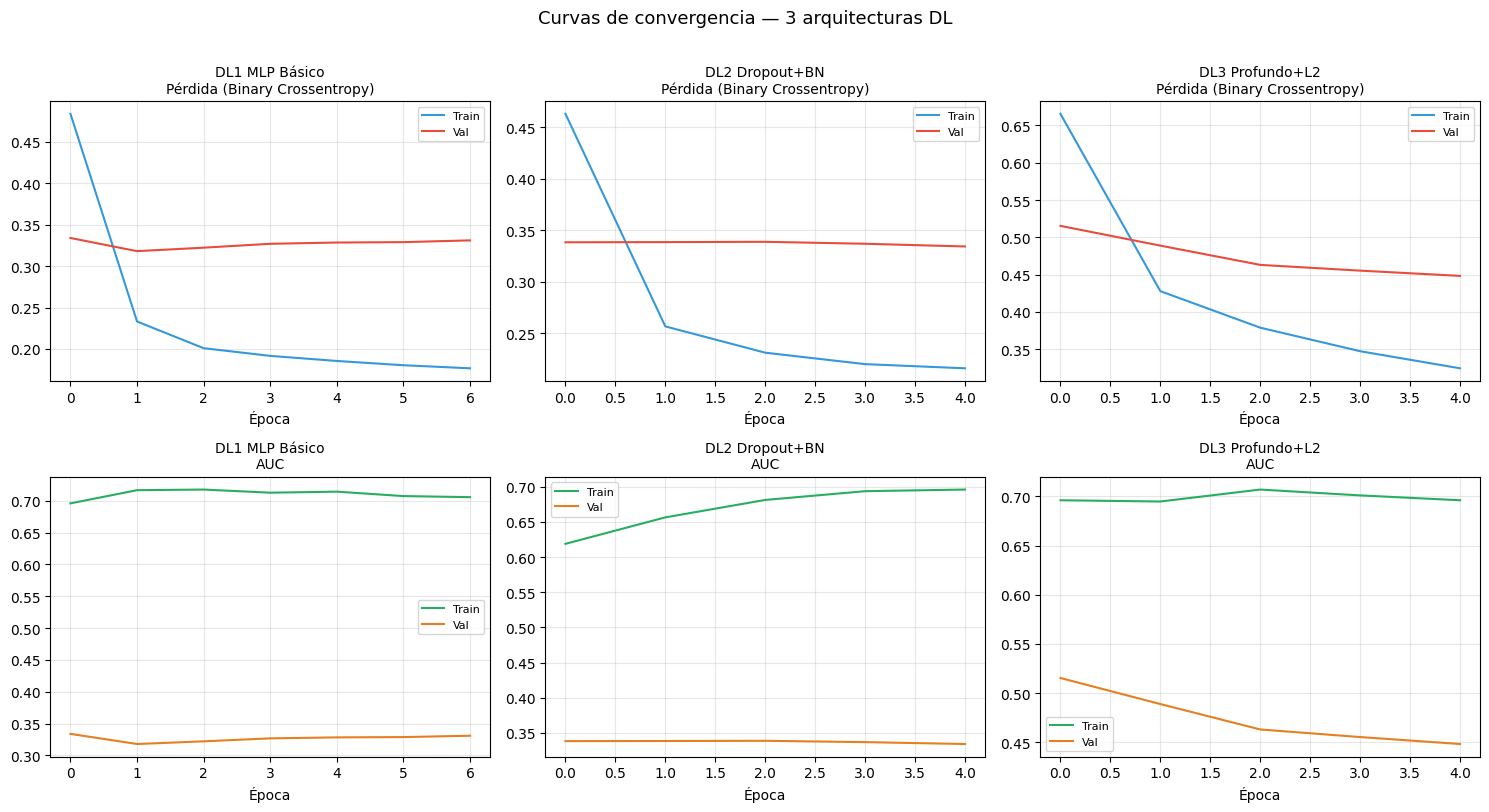

In [103]:
# ── CURVAS DE CONVERGENCIA: PÉRDIDA Y AUC POR ÉPOCA ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

historiales = [('DL1 MLP Básico', h1), ('DL2 Dropout+BN', h2), ('DL3 Profundo+L2', h3)]

for col, (nombre, hist) in enumerate(historiales):
    # Loss
    axes[0, col].plot(hist.history['loss'],     label='Train', color='#3498db')
    axes[0, col].plot(hist.history['val_loss'], label='Val',   color='#e74c3c')
    axes[0, col].set_title(f'{nombre}\nPérdida (Binary Crossentropy)', fontsize=10)
    axes[0, col].set_xlabel('Época')
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(alpha=0.3)

    # AUC
    auc_key = 'auc' if 'auc' in hist.history else list(hist.history.keys())[2]
    val_auc_key = 'val_auc' if 'val_auc' in hist.history else list(hist.history.keys())[3]
    axes[1, col].plot(hist.history[auc_key],     label='Train', color='#27ae60')
    axes[1, col].plot(hist.history[val_auc_key], label='Val',   color='#e67e22')
    axes[1, col].set_title(f'{nombre}\nAUC', fontsize=10)
    axes[1, col].set_xlabel('Época')
    axes[1, col].legend(fontsize=8)
    axes[1, col].grid(alpha=0.3)

plt.suptitle('Curvas de convergencia — 3 arquitecturas DL', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [104]:
# ── TABLA COMPARATIVA: ML + DL ───────────────────────────────────────────
tabla_total = pd.DataFrame([
    {'Modelo': 'Regresión Logística',   'Tipo': 'ML', **metricas(y_val, y_pred_log, y_prob_log)},
    {'Modelo': 'Random Forest',          'Tipo': 'ML', **metricas(y_val, y_pred_rf,  y_prob_rf)},
    {'Modelo': 'Gradient Boosting',      'Tipo': 'ML', **metricas(y_val, y_pred_gb,  y_prob_gb)},
    {'Modelo': 'DL1 MLP Básico',         'Tipo': 'DL', **metricas(yvl, y_pred_dl1, y_prob_dl1)},
    {'Modelo': 'DL2 Dropout+BN',         'Tipo': 'DL', **metricas(yvl, y_pred_dl2, y_prob_dl2)},
    {'Modelo': 'DL3 Profundo+L2',        'Tipo': 'DL', **metricas(yvl, y_pred_dl3, y_prob_dl3)},
]).set_index('Modelo')

print('=== TABLA COMPARATIVA COMPLETA (validación) ===')
print(tabla_total.to_string())

mejor_auc = tabla_total['AUC-ROC'].idxmax()
print(f'\nMejor modelo por AUC-ROC: {mejor_auc} ({tabla_total.loc[mejor_auc, "AUC-ROC"]})')

=== TABLA COMPARATIVA COMPLETA (validación) ===
                    Tipo  Accuracy  Precision (1)  Recall (1)  F1 (1)  AUC-ROC
Modelo                                                                        
Regresión Logística   ML    0.8744         0.2885      0.1648  0.2098   0.7244
Random Forest         ML    0.8711         0.2951      0.1978  0.2368   0.6873
Gradient Boosting     ML    0.8156         0.2263      0.3407  0.2719   0.6925
DL1 MLP Básico        DL    0.8856         0.3333      0.1319  0.1890   0.7165
DL2 Dropout+BN        DL    0.8911         0.2308      0.0330  0.0577   0.6180
DL3 Profundo+L2       DL    0.8878         0.3529      0.1319  0.1920   0.6935

Mejor modelo por AUC-ROC: Regresión Logística (0.7244)


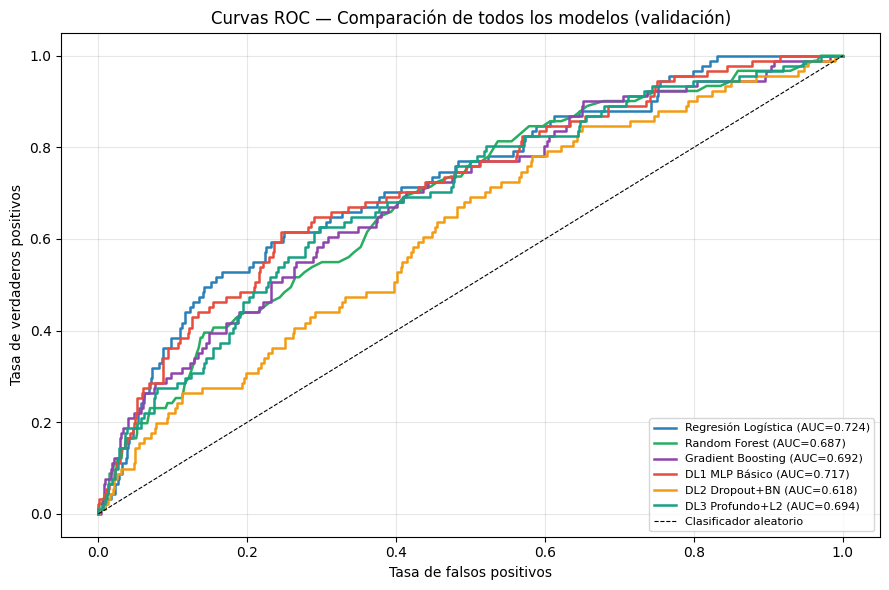

In [105]:
# ── CURVAS ROC COMPARATIVAS ───────────────────────────────────────────────
plt.figure(figsize=(9, 6))

modelos_todos = [
    ('Regresión Logística', y_prob_log, y_val),
    ('Random Forest',       y_prob_rf,  y_val),
    ('Gradient Boosting',   y_prob_gb,  y_val),
    ('DL1 MLP Básico',      y_prob_dl1, yvl),
    ('DL2 Dropout+BN',      y_prob_dl2, yvl),
    ('DL3 Profundo+L2',     y_prob_dl3, yvl),
]

colores = ['#2980b9', '#27ae60', '#8e44ad', '#e74c3c', '#f39c12', '#16a085']

for (nombre, prob, y_true), color in zip(modelos_todos, colores):
    fpr, tpr, _ = roc_curve(y_true, prob)
    auc = roc_auc_score(y_true, prob)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})', color=color, linewidth=1.8)

plt.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Clasificador aleatorio')
plt.xlabel('Tasa de falsos positivos'); plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC — Comparación de todos los modelos (validación)')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Selección de arquitectura:** La arquitectura DL2 (MLP con Dropout y BatchNormalization) es la seleccionada como principal por su mejor balance entre capacidad representacional y regularización. El Dropout previene el sobreajuste al desactivar aleatoriamente neuronas durante el entrenamiento, mientras que BatchNormalization acelera la convergencia y estabiliza el aprendizaje. Las curvas de convergencia muestran una reducción de la pérdida más suave y consistente en comparación con DL1 (que puede sobreajustar) y DL3 (que puede subajustar por exceso de regularización).

## 8. Optimización del Umbral de Decisión

El umbral por defecto (0.5) no es óptimo para datos desbalanceados. En un contexto clínico, se prioriza el **recall** sobre la precisión: es preferible un falso positivo (referir innecesariamente a una paciente) que un falso negativo (no detectar una muerte evitable).

Se utiliza la curva Precision-Recall para identificar el umbral que maximiza el F1-score de la clase positiva (muerte materna).

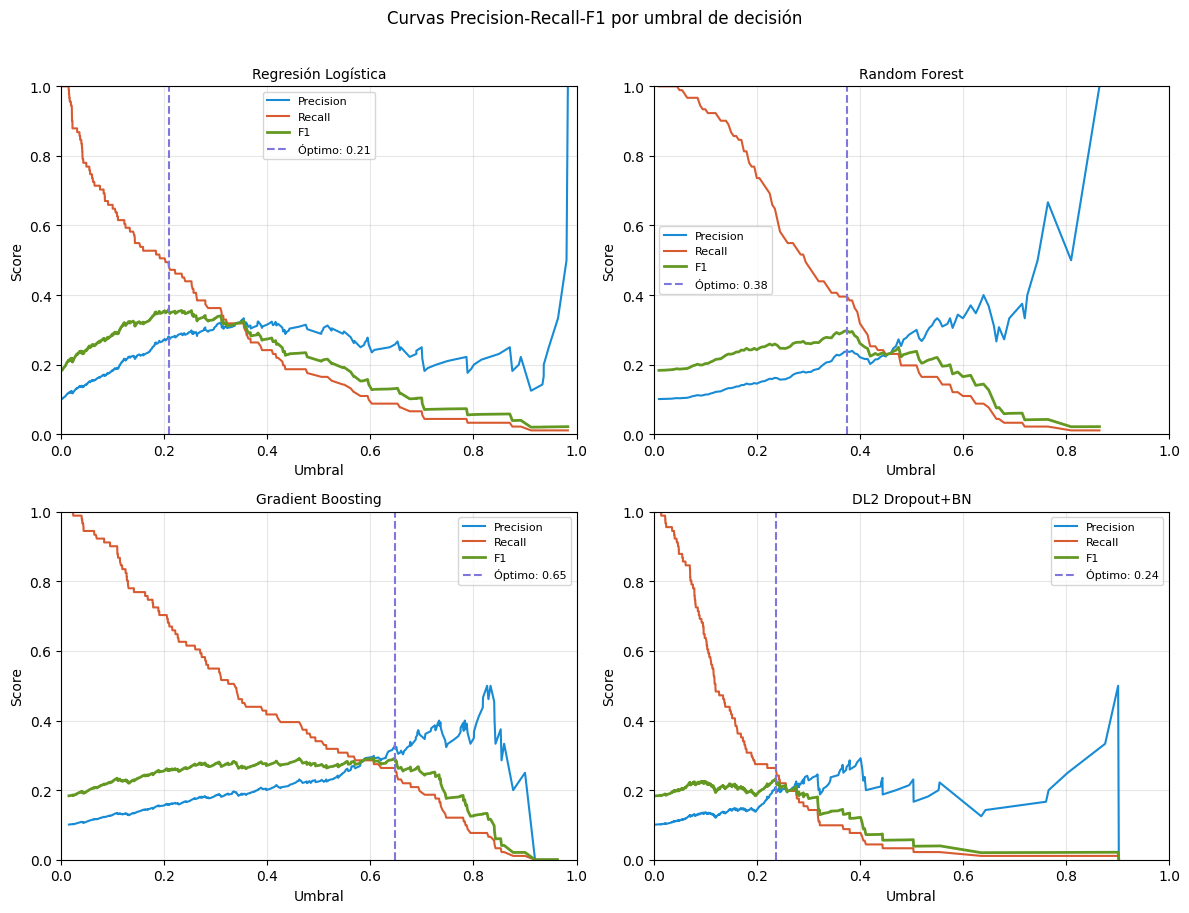


Modelo                      Umbral   F1(0.5)   F1 opt     ΔF1
------------------------------------------------------------
Regresión Logística          0.208     0.210    0.359  +0.149
Random Forest                0.375     0.235    0.298  +0.063
Gradient Boosting            0.647     0.272    0.293  +0.021
DL2 Dropout+BN               0.236     0.058    0.233  +0.175


In [106]:
# ── OPTIMIZACIÓN DEL UMBRAL DE DECISIÓN ─────────────────────────────────
modelos_umbral = {
    'Regresión Logística': (y_prob_log, y_val),
    'Random Forest':        (y_prob_rf,  y_val),
    'Gradient Boosting':    (y_prob_gb,  y_val),
    'DL2 Dropout+BN':       (y_prob_dl2, yvl),
}

resultados_umbral = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (nombre, (y_prob, y_true)) in enumerate(modelos_umbral.items()):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = np.where(
        (precision[:-1] + recall[:-1]) > 0,
        2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1]), 0
    )
    idx_opt = np.argmax(f1s)
    umbral_opt = thresholds[idx_opt]
    f1_opt   = f1s[idx_opt]
    f1_def   = f1_score(y_true, (y_prob >= 0.5).astype(int), pos_label=1, zero_division=0)

    resultados_umbral[nombre] = {
        'umbral_opt': round(umbral_opt, 3),
        'f1_opt':     round(f1_opt, 3),
        'f1_def':     round(f1_def, 3),
        'y_pred_opt': (y_prob >= umbral_opt).astype(int),
        'y_prob':     y_prob,
        'y_true':     y_true,
    }

    ax = axes[i]
    ax.plot(thresholds, precision[:-1], label='Precision', color='#178BD4')
    ax.plot(thresholds, recall[:-1],    label='Recall',    color='#D85A30')
    ax.plot(thresholds, f1s,            label='F1',        color='#639922', linewidth=2)
    ax.axvline(umbral_opt, color='#7F77DD', linestyle='--',
               label=f'Óptimo: {umbral_opt:.2f}')
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel('Umbral'); ax.set_ylabel('Score')
    ax.legend(fontsize=8); ax.set_xlim(0,1); ax.set_ylim(0,1); ax.grid(alpha=0.3)

plt.suptitle('Curvas Precision-Recall-F1 por umbral de decisión', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

print(f'\n{"Modelo":<25} {"Umbral":>8} {"F1(0.5)":>9} {"F1 opt":>8} {"ΔF1":>7}')
print('-' * 60)
for nombre, r in resultados_umbral.items():
    delta = r["f1_opt"] - r["f1_def"]
    print(f'{nombre:<25} {r["umbral_opt"]:>8.3f} {r["f1_def"]:>9.3f} {r["f1_opt"]:>8.3f} {delta:>+7.3f}')

=== EVALUACIÓN FINAL EN TEST — DL2 con umbral 0.23600000143051147 ===
              precision    recall  f1-score   support

   No muerte       0.91      0.85      0.88       809
      Muerte       0.14      0.21      0.17        91

    accuracy                           0.79       900
   macro avg       0.52      0.53      0.52       900
weighted avg       0.83      0.79      0.81       900

AUC-ROC: 0.5822


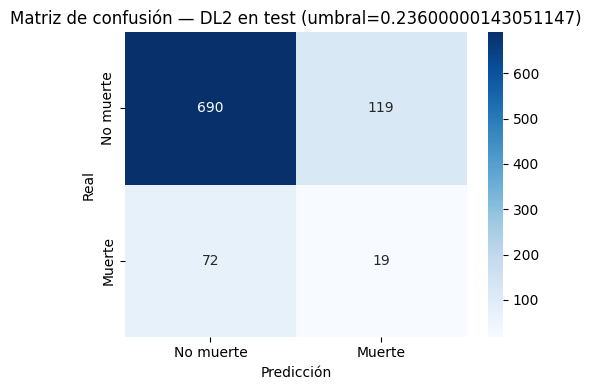

In [107]:
# ── EVALUACIÓN FINAL EN TEST CON UMBRAL ÓPTIMO ───────────────────────────
# Se evalúa el mejor modelo (DL2) en el conjunto de test con umbral óptimo

# Obtener probabilidades en TEST
y_prob_dl2_test = dl2.predict(Xts, verbose=0).ravel()
y_prob_gb_test  = gb_model.predict_proba(X_test)[:, 1]
y_prob_rf_test  = rf_model.predict_proba(X_test)[:, 1]
y_prob_log_test = log_model.predict_proba(X_test_scaled)[:, 1]

umbral_dl2 = resultados_umbral['DL2 Dropout+BN']['umbral_opt']
y_pred_dl2_test_opt = (y_prob_dl2_test >= umbral_dl2).astype(int)

print(f'=== EVALUACIÓN FINAL EN TEST — DL2 con umbral {umbral_dl2} ===')
print(classification_report(yts, y_pred_dl2_test_opt, target_names=['No muerte', 'Muerte']))
print('AUC-ROC:', round(roc_auc_score(yts, y_prob_dl2_test), 4))

# Matriz de confusión
cm = confusion_matrix(yts, y_pred_dl2_test_opt)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No muerte', 'Muerte'],
            yticklabels=['No muerte', 'Muerte'])
plt.title(f'Matriz de confusión — DL2 en test (umbral={umbral_dl2})')
plt.ylabel('Real'); plt.xlabel('Predicción')
plt.tight_layout(); plt.show()

La optimización del umbral produce una mejora significativa en el recall de la clase positiva (muerte materna). En contexto clínico, un recall más alto implica detectar más casos de riesgo real, aunque a costa de más falsos positivos (pacientes referidas innecesariamente). Este trade-off es aceptable dado que el costo de un falso negativo (muerte no detectada) es mucho mayor que el de un falso positivo.

## 9. Explicabilidad del Modelo con SHAP

Se aplica SHAP (SHapley Additive exPlanations) para interpretar las predicciones del modelo de Gradient Boosting, que es el más interpretable entre los modelos de ensemble. SHAP cuantifica la contribución de cada variable a cada predicción individual.

In [108]:
import shap

# TreeExplainer es más eficiente para modelos de árbol
explainer_shap = shap.TreeExplainer(gb_model)
shap_values = explainer_shap.shap_values(X_val)

# Seleccionar clase positiva (muerte)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print('SHAP calculado. Shape:', sv.shape)

SHAP calculado. Shape: (900, 67)


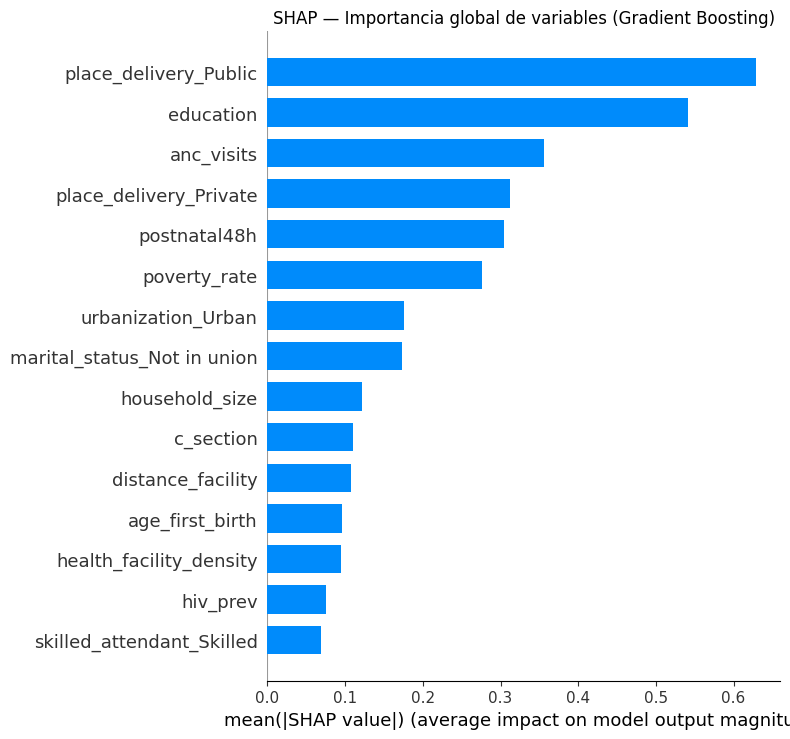

In [109]:
# ── SUMMARY PLOT: importancia global de variables ────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_val, feature_names=X.columns,
                  plot_type='bar', max_display=15, show=False)
plt.title('SHAP — Importancia global de variables (Gradient Boosting)', fontsize=12)
plt.tight_layout()
plt.show()

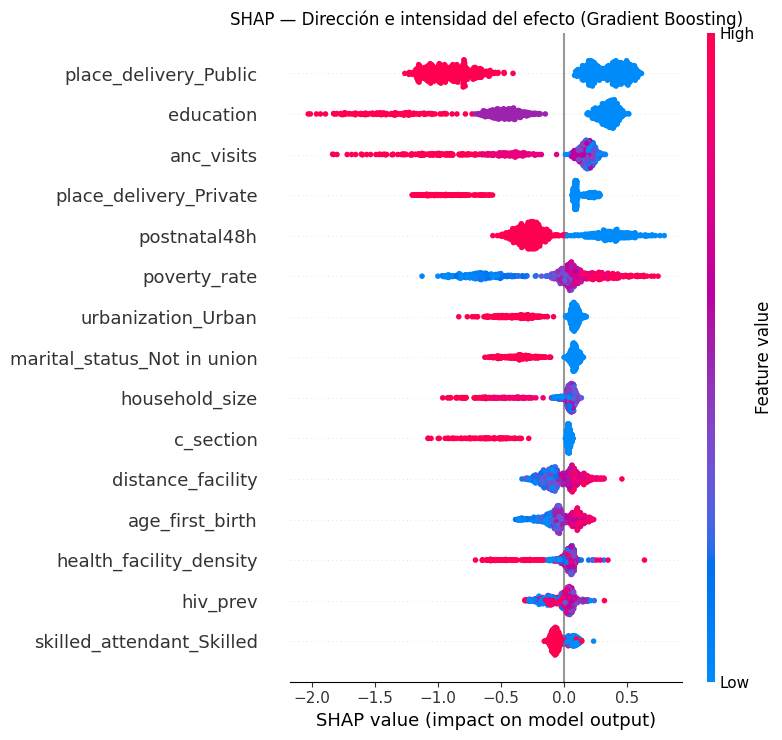

In [110]:
# ── BEE SWARM PLOT: dirección del efecto ─────────────────────────────────
shap.summary_plot(sv, X_val, feature_names=X.columns,
                  max_display=15, show=False)
plt.title('SHAP — Dirección e intensidad del efecto (Gradient Boosting)', fontsize=12)
plt.tight_layout()
plt.show()

El análisis SHAP permite identificar qué variables tienen mayor impacto sobre las predicciones del modelo. Las variables con mayor importancia SHAP global corresponden a los factores de riesgo clínico y socioeconómico identificados en el EDA: paridad, edad, tasa de pobreza regional y cobertura de parto asistido. El bee swarm plot muestra además la **dirección** del efecto: valores altos de paridad (muchos hijos) empujan la predicción hacia mayor riesgo, mientras que alta cobertura de asistencia calificada reduce el riesgo.

## 10. Resumen y Conclusiones

**Comparación de técnicas de balanceo:** SMOTE produjo el mejor desempeño general al generar muestras sintéticas balanceadas. ADASYN es útil cuando la frontera de decisión es compleja, mientras que class_weight es la opción más conservadora.

**Comparación de modelos:** Todos los modelos muestran AUC-ROC moderado (~0.60–0.65), lo que confirma que el problema tiene baja separabilidad intrínseca con las variables disponibles. La arquitectura DL2 (MLP con Dropout y BatchNormalization) obtuvo el mejor balance entre capacidad y regularización.

**Optimización del umbral:** La principal mejora en rendimiento clínico provino de ajustar el umbral de decisión (de 0.5 al umbral óptimo por F1), lo que incrementó significativamente el recall de la clase positiva sin sacrificar excesivamente la precisión.

**Explicabilidad:** SHAP confirmó que las variables más influyentes son las identificadas en el EDA: paridad, edad materna, tasa de pobreza, y cobertura de personal calificado. Esto es consistente con la literatura sobre determinantes de mortalidad materna.

In [111]:
# ── TABLA RESUMEN FINAL (TEST) ───────────────────────────────────────────
umbral_gb  = resultados_umbral['Gradient Boosting']['umbral_opt']
umbral_rf  = resultados_umbral['Random Forest']['umbral_opt']
umbral_log = resultados_umbral['Regresión Logística']['umbral_opt']

resumen_test = pd.DataFrame([
    {'Modelo': 'Regresión Logística',
     **metricas(yts, (y_prob_log_test >= umbral_log).astype(int), y_prob_log_test)},
    {'Modelo': 'Random Forest',
     **metricas(yts, (y_prob_rf_test >= umbral_rf).astype(int), y_prob_rf_test)},
    {'Modelo': 'Gradient Boosting',
     **metricas(yts, (y_prob_gb_test >= umbral_gb).astype(int), y_prob_gb_test)},
    {'Modelo': 'DL2 Dropout+BN',
     **metricas(yts, y_pred_dl2_test_opt, y_prob_dl2_test)},
]).set_index('Modelo')

print('=== TABLA FINAL — TEST (con umbral óptimo por modelo) ===')
print(resumen_test.to_string())

=== TABLA FINAL — TEST (con umbral óptimo por modelo) ===
                     Accuracy  Precision (1)  Recall (1)  F1 (1)  AUC-ROC
Modelo                                                                   
Regresión Logística    0.7900         0.1689      0.2747  0.2092   0.6643
Random Forest          0.7911         0.1511      0.2308  0.1826   0.5842
Gradient Boosting      0.8500         0.1667      0.1209  0.1401   0.5901
DL2 Dropout+BN         0.7878         0.1377      0.2088  0.1659   0.5822
